# Homework 1 — Evaluation & Comparison (4 Points)

Compare the two trained models (scratch vs pretrained) and analyze their performance.

**Tasks:**
1. Compare training curves side by side
2. Show confusion matrix for both models
3. Discuss: Which classes are hardest? Why?

**Deliverables:**
- 3 Jupyter notebooks exported as **HTML**
- 1-page **PDF report**: summarize results, comparison, and key observations

## Setup

In [1]:
import timm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
)

NUM_CLASSES = 21
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/home/vscode/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load Both Models and Test Data

In [2]:
# TODO: Load the scratch model — fill in the filename
model_scratch = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_scratch.load_state_dict(torch.load("uc_merced_scratch.pth", map_location=device))
model_scratch = model_scratch.to(device)
model_scratch.eval()

# TODO: Load the pretrained model — fill in the filename
model_pretrained = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_pretrained.load_state_dict(torch.load("uc_merced_pretrained.pth", map_location=device))
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

# Test data
config = timm.data.resolve_model_data_config(model_scratch)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

class_names = test_ds.classes
print(f"Test samples: {len(test_ds)}")
print(f"Classes: {class_names}")

Test samples: 315
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [3]:
def get_predictions(model, loader):
    """Run inference, return (preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            all_preds.extend(model(images).argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_preds, all_labels

preds_scratch, labels_scratch = get_predictions(model_scratch, test_loader)
preds_pretrained, labels_pretrained = get_predictions(model_pretrained, test_loader)

print("=== From Scratch ===")
print(f"  Accuracy:          {accuracy_score(labels_scratch, preds_scratch):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_scratch, preds_scratch):.2%}")

print("\n=== Pretrained ===")
print(f"  Accuracy:          {accuracy_score(labels_pretrained, preds_pretrained):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_pretrained, preds_pretrained):.2%}")

=== From Scratch ===
  Accuracy:          34.60%
  Balanced Accuracy: 34.60%

=== Pretrained ===
  Accuracy:          95.87%
  Balanced Accuracy: 95.87%


## 2. Training Curves: Side by Side

Load the training history CSVs saved by `01_TrainModel.ipynb`.

In [ ]:
# TODO: Fill in the CSV filenames saved by 01_TrainModel.ipynb
history_scratch = pd.read_csv("history_scratch.csv").to_dict(orient="list")
history_pretrained = pd.read_csv("history_pretrained.csv").to_dict(orient="list")

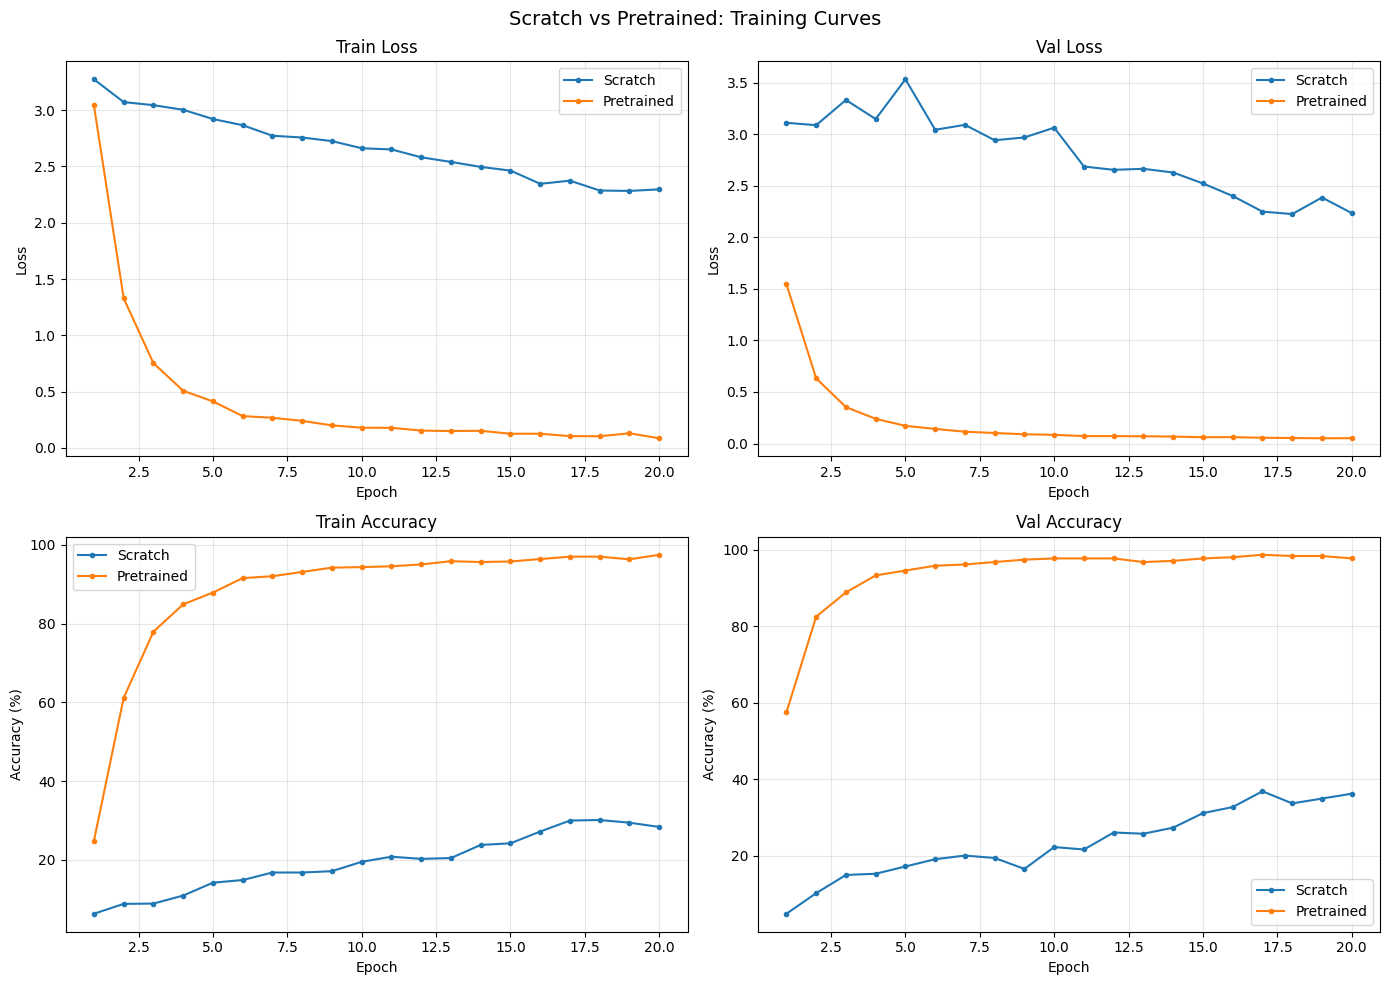

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep_s = range(1, len(history_scratch["train_loss"]) + 1)
ep_p = range(1, len(history_pretrained["train_loss"]) + 1)

titles = ["Train Loss", "Val Loss", "Train Accuracy", "Val Accuracy"]
keys = ["train_loss", "val_loss", "train_acc", "val_acc"]
ylabels = ["Loss", "Loss", "Accuracy (%)", "Accuracy (%)"]

for ax, title, key, ylabel in zip(axes.flatten(), titles, keys, ylabels):
    ax.plot(ep_s, history_scratch[key], label="Scratch", marker='o', ms=3)
    ax.plot(ep_p, history_pretrained[key], label="Pretrained", marker='o', ms=3)
    ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Scratch vs Pretrained: Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Confusion Matrices

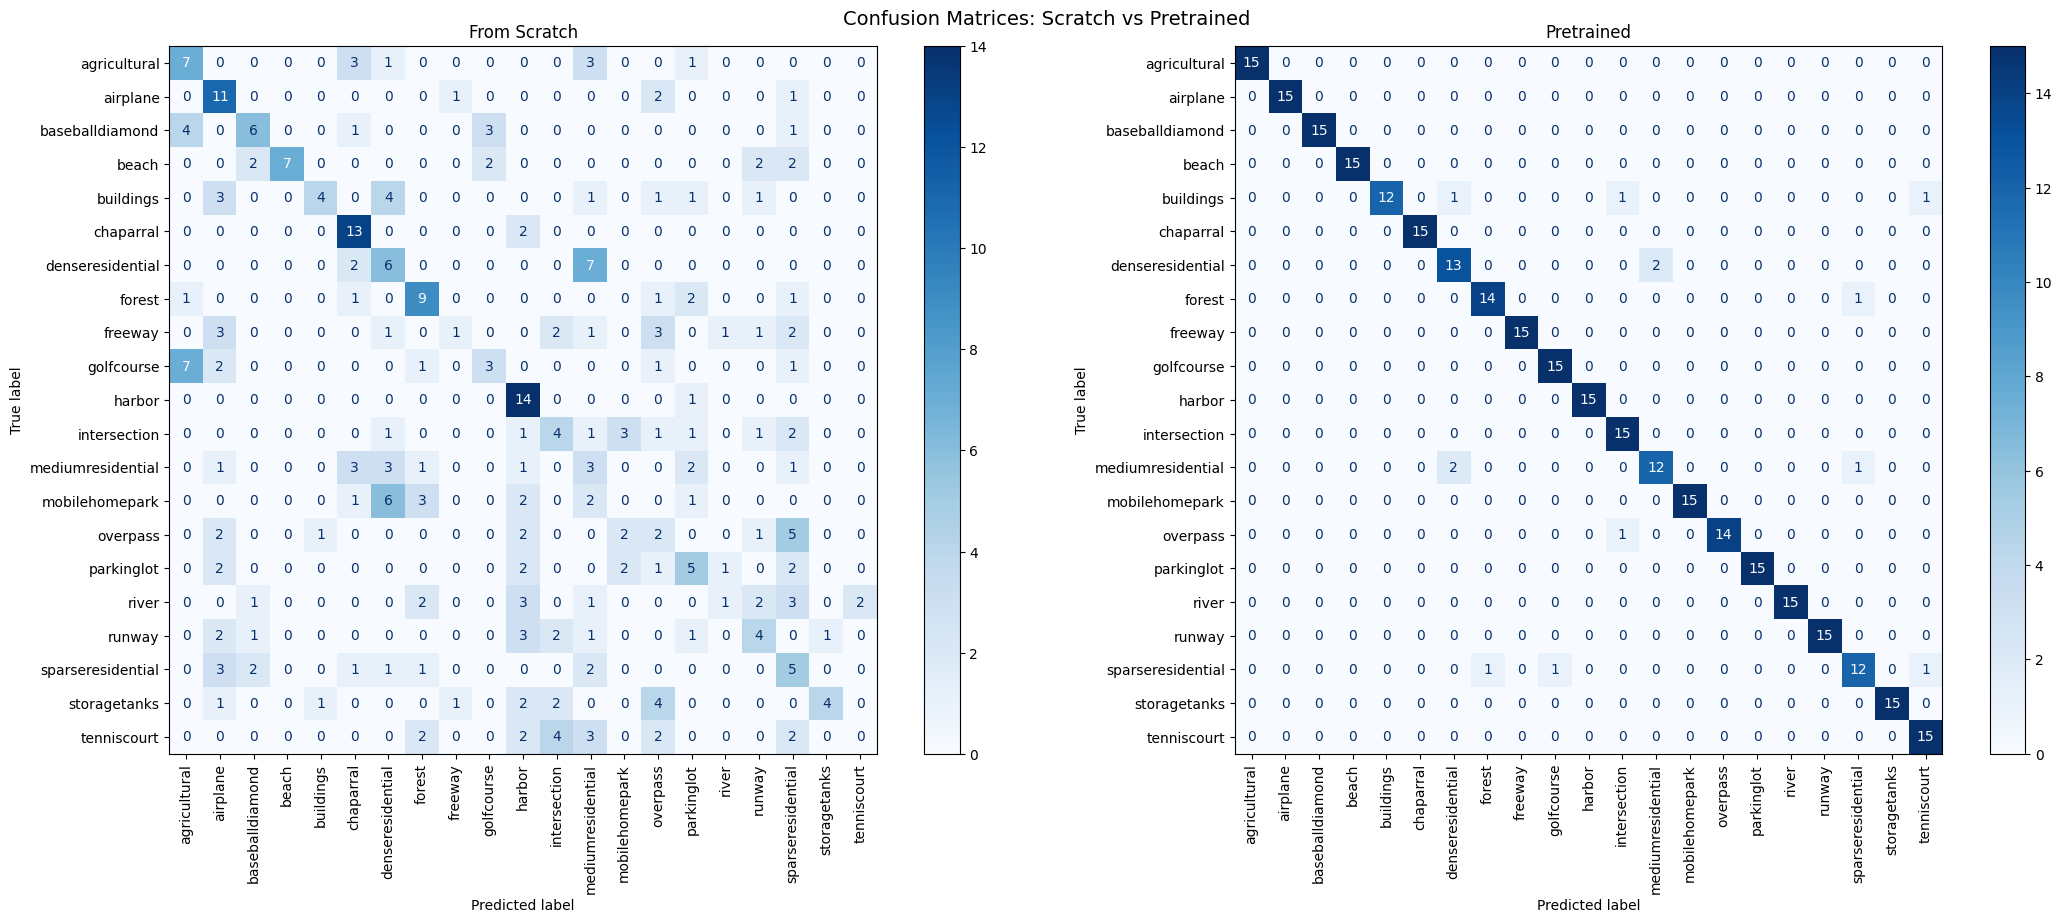

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

cm_scratch = confusion_matrix(labels_scratch, preds_scratch)
ConfusionMatrixDisplay(cm_scratch, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax1, xticks_rotation=90)
ax1.set_title("From Scratch")

cm_pretrained = confusion_matrix(labels_pretrained, preds_pretrained)
ConfusionMatrixDisplay(cm_pretrained, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax2, xticks_rotation=90)
ax2.set_title("Pretrained")

fig.suptitle("Confusion Matrices: Scratch vs Pretrained", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
print("=== Classification Report: From Scratch ===")
print(classification_report(labels_scratch, preds_scratch, target_names=class_names))

print("\n=== Classification Report: Pretrained ===")
print(classification_report(labels_pretrained, preds_pretrained, target_names=class_names))

=== Classification Report: From Scratch ===
                   precision    recall  f1-score   support

     agricultural       0.37      0.47      0.41        15
         airplane       0.37      0.73      0.49        15
  baseballdiamond       0.50      0.40      0.44        15
            beach       1.00      0.47      0.64        15
        buildings       0.67      0.27      0.38        15
        chaparral       0.52      0.87      0.65        15
 denseresidential       0.26      0.40      0.32        15
           forest       0.47      0.60      0.53        15
          freeway       0.33      0.07      0.11        15
       golfcourse       0.38      0.20      0.26        15
           harbor       0.41      0.93      0.57        15
     intersection       0.29      0.27      0.28        15
mediumresidential       0.12      0.20      0.15        15
   mobilehomepark       0.00      0.00      0.00        15
         overpass       0.11      0.13      0.12        15
       park

## 4. Discussion

**a) Accuracy & Convergence:**

The pretrained model achieves 95.87% test accuracy versus 34.60% for the scratch model. Transfer learning from ImageNet provides strong low-level feature initialization, so the pretrained model reaches high validation accuracy within the first few epochs. The scratch model improved much more slowly. Which is expected given the small dataset (~1470 training images across 21 classes): training a deep CNN from random weights on ~70 images per class is severely data-limited.

**b) Hardest Classes:**

The two hardest classes for the scratch model are `mobilehomepark` and `tenniscourt`, both scoring **F1 = 0.00** — the model achieves zero recall on every test sample for these classes. Close behind are `freeway` (0.11), `river` (0.11), and `overpass` (0.12). The three residential density classes (`mediumresidential` 0.15, `sparseresidential` 0.23, `denseresidential` 0.32) are also consistently low, as they share the same overhead perspective and differ only in building density — a subtle distinction that requires learned texture features the scratch model fails to acquire.

For the pretrained model, the bottom four are `buildings` (F1 0.89), `denseresidential` (0.84), `mediumresidential` (0.83), and `sparseresidential` (0.83). These are the only classes where the pretrained model makes any notable errors, and they all involve residential/urban textures that are genuinely ambiguous even at aerial scale.

**c) Pretrained vs Scratch:**

Transfer learning acheaves 60% more accuracy than from scratch. The most striking gains are on classes the scratch model fails entirely: `mobilehomepark` goes from F1 0.00 to 1.00, `tenniscourt` from 0.00 to 0.94, `freeway` from 0.11 to 1.00, `river` from 0.11 to 1.00, and `storagetanks` from 0.40 to 1.00. These classes have distinctive geometric or texture signatures (regular court markings, cylindrical tanks, linear water channels) that ImageNet pretraining encodes well, and which the scratch model never learns from so few examples. The one exception is the residential class cluster — even the pretrained model finds `buildings`, `denseresidential`, `mediumresidential`, and `sparseresidential` difficult, because their differences are ones of degree rather than kind, and ImageNet contains no direct analogues for overhead density gradients.